# 10 — Dataset Characteristics: Visualizations (Paper §4.1)

Generates the figures backing Section 4.1: annual chat volume, tournament-tier
distribution, gold sentiment / toxicity class balance, Dota-jargon share, English
vs non-English split, and a combined multi-panel figure for the manuscript.

Outputs (`reports/plots/`): `dataset_annual_volume.png`, `dataset_tier_distribution.png`,
`dataset_sentiment_distribution.png`, `dataset_toxicity_distribution.png`,
`dataset_language_split.png`, `dataset_characteristics_panel.png`.

In [1]:
# Setup
import sys
from pathlib import Path
_here = Path.cwd()
_root = next((p for p in [_here, *_here.parents] if (p / 'src').is_dir() and (p / 'configs').is_dir()), _here)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
import os
os.chdir(_root)

from src.runtime import load_config, print_banner, RunLog
config = load_config('configs/experiment.yaml')
print_banner('10_dataset_characteristics', config)
run_log = RunLog(notebook='10_dataset_characteristics', config_path='configs/experiment.yaml')

import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10,
                     'axes.grid': True, 'grid.alpha': 0.3, 'axes.axisbelow': True})

PROC = Path(config['data']['processed_root'])
GOLD = Path(config['data']['gold_root'])
PLOTS = Path('reports') / 'plots'
PLOTS.mkdir(parents=True, exist_ok=True)
SENT = config['labels']['sentiment_classes']
TOX = config['labels']['toxicity_labels']

C_BLUE, C_RED, C_GREY, C_ORANGE = '#3a7ca5', '#d1495b', '#b0b0b0', '#e3902f'

c:\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Notebook: 10_dataset_characteristics
Experiment: thesis-sentiment-toxicity-dota2-decade
Seed: 42  |  Git: da158c0
Started at: 2026-06-10T08:47:23+00:00Z
Versi paket:
  - python: 3.10.0
  - transformers: 5.5.0
  - torch: 2.8.0+cu128
  - datasets: 4.8.5
  - scikit-learn: 1.7.1
  - pandas: 2.3.3
  - numpy: 1.26.4


In [2]:
# Corpus aggregates (English + non-English processed parquets)
en_files = sorted(p for p in glob.glob(str(PROC / '[0-9]*.parquet')) if 'non_english' not in p)
ne_files = sorted(glob.glob(str(PROC / '*_non_english.parquet')))
TIER_MAP = {'Lainnya': 'Other', 'TI': 'The International', 'Major': 'Major',
            'DPC Tour': 'DPC Tour', 'DPC League': 'DPC Tour', 'Tour': 'DPC Tour'}

year_counts, tier_counts, en_total = {}, {}, 0
for f in en_files:
    d = pd.read_parquet(f, columns=['year', 'tier'])
    en_total += len(d)
    for y, c in d['year'].value_counts().items():
        year_counts[int(y)] = year_counts.get(int(y), 0) + int(c)
    for t, c in d['tier'].value_counts().items():
        k = TIER_MAP.get(t, str(t))
        tier_counts[k] = tier_counts.get(k, 0) + int(c)

ne_total, lang_counts = 0, {}
for f in ne_files:
    d = pd.read_parquet(f, columns=['lang'])
    ne_total += len(d)
    for l, c in d['lang'].value_counts().items():
        lang_counts[l] = lang_counts.get(l, 0) + int(c)

yr = pd.Series(year_counts).sort_index()
tier = pd.Series(tier_counts).sort_values(ascending=False)
lang = pd.Series(lang_counts).sort_values(ascending=False)
print(f'English corpus: {en_total:,}  |  non-English: {ne_total:,}')
print('Tier (%):'); print((100 * tier / tier.sum()).round(2).to_string())

English corpus: 1,603,567  |  non-English: 274,087
Tier (%):
Other                92.04
DPC Tour              3.93
Major                 2.36
The International     1.67


In [3]:
# Gold-standard aggregates
train = pd.read_csv(GOLD / 'train.csv')
test = pd.read_csv(GOLD / 'test.csv')
gold = pd.concat([train, test], ignore_index=True)
n_gold = len(gold)

sent_counts = gold['sentiment'].value_counts().reindex(SENT).fillna(0).astype(int)
tox_counts = pd.Series({l: int(gold[f'tox_{l}'].sum()) for l in TOX})
jargon = int(gold['is_dota_jargon'].sum())
print(f'Gold n={n_gold}  (train {len(train)}, test {len(test)})')
print('Sentiment:'); print(sent_counts.to_string())
print('Toxicity positives:'); print(tox_counts.to_string())
print(f'Dota-jargon-bearing: {jargon} ({100*jargon/n_gold:.1f}%)')

Gold n=7971  (train 5579, test 2392)
Sentiment:
sentiment
negative     102
neutral     3357
positive    4512
Toxicity positives:
toxic            68
severe_toxic      0
obscene          53
threat            0
insult           66
identity_hate     2
Dota-jargon-bearing: 4257 (53.4%)


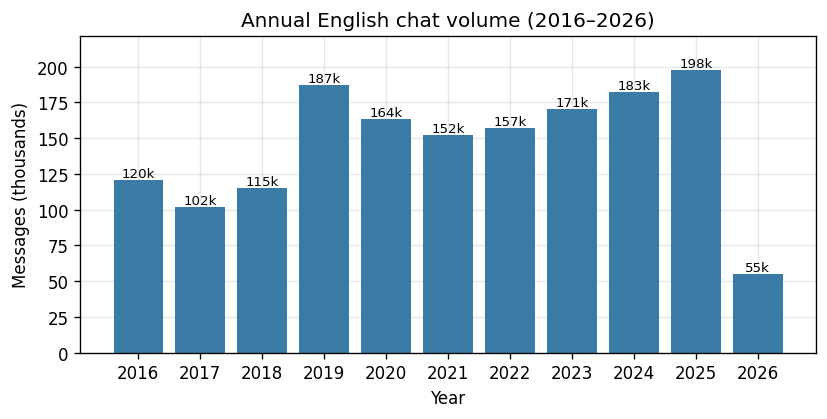

In [4]:
# Fig 1 — Annual English chat volume
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.bar(yr.index.astype(str), yr.values / 1000, color=C_BLUE)
for i, v in enumerate(yr.values):
    ax.text(i, v / 1000, f'{v/1000:.0f}k', ha='center', va='bottom', fontsize=8)
ax.set_xlabel('Year'); ax.set_ylabel('Messages (thousands)')
ax.set_title('Annual English chat volume (2016–2026)')
ax.margins(y=0.12)
plt.tight_layout(); fig.savefig(PLOTS / 'dataset_annual_volume.png'); plt.show()
run_log.add_output(PLOTS / 'dataset_annual_volume.png')

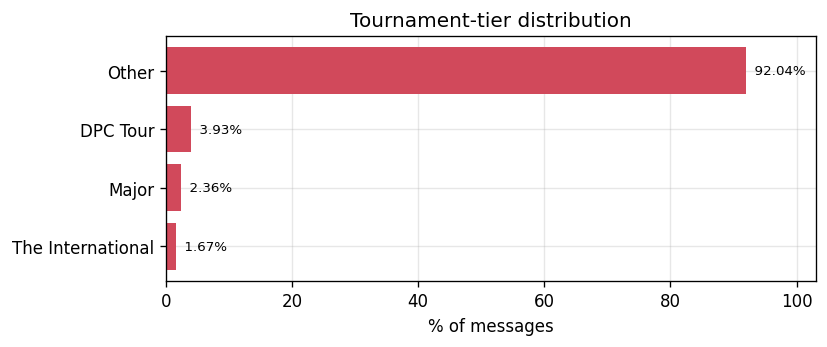

In [5]:
# Fig 2 — Tournament tier distribution
pct = (100 * tier / tier.sum()).sort_values()
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(pct.index, pct.values, color=C_RED)
for i, v in enumerate(pct.values):
    ax.text(v, i, f'  {v:.2f}%', va='center', fontsize=8)
ax.set_xlabel('% of messages'); ax.set_title('Tournament-tier distribution')
ax.margins(x=0.12)
plt.tight_layout(); fig.savefig(PLOTS / 'dataset_tier_distribution.png'); plt.show()
run_log.add_output(PLOTS / 'dataset_tier_distribution.png')

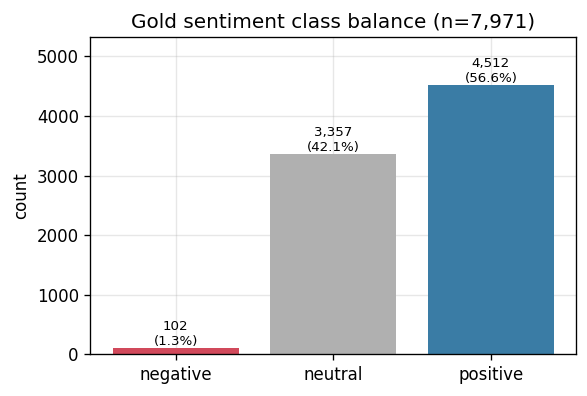

In [6]:
# Fig 3 — Gold sentiment distribution
cmap = {'negative': C_RED, 'neutral': C_GREY, 'positive': C_BLUE}
fig, ax = plt.subplots(figsize=(5, 3.4))
ax.bar(sent_counts.index, sent_counts.values, color=[cmap[s] for s in sent_counts.index])
for i, v in enumerate(sent_counts.values):
    ax.text(i, v, f'{v:,}\n({100*v/n_gold:.1f}%)', ha='center', va='bottom', fontsize=8)
ax.set_ylabel('count'); ax.set_title(f'Gold sentiment class balance (n={n_gold:,})')
ax.margins(y=0.18)
plt.tight_layout(); fig.savefig(PLOTS / 'dataset_sentiment_distribution.png'); plt.show()
run_log.add_output(PLOTS / 'dataset_sentiment_distribution.png')

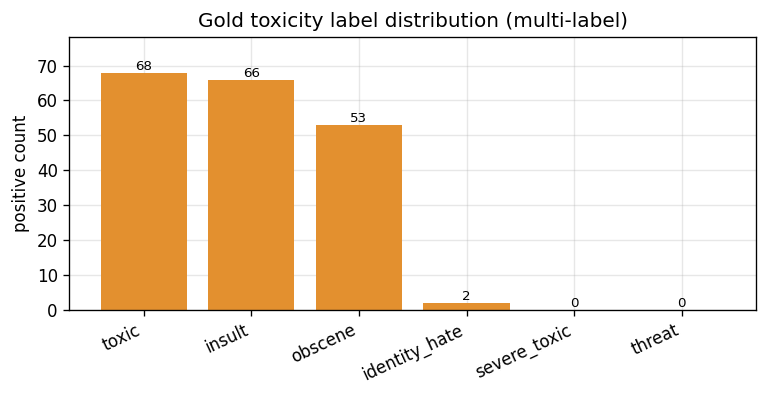

In [7]:
# Fig 4 — Gold toxicity label distribution (multi-label)
tc = tox_counts.sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.bar(tc.index, tc.values, color=C_ORANGE)
for i, v in enumerate(tc.values):
    ax.text(i, v, str(v), ha='center', va='bottom', fontsize=8)
ax.set_ylabel('positive count'); ax.set_title('Gold toxicity label distribution (multi-label)')
plt.xticks(rotation=25, ha='right'); ax.margins(y=0.15)
plt.tight_layout(); fig.savefig(PLOTS / 'dataset_toxicity_distribution.png'); plt.show()
run_log.add_output(PLOTS / 'dataset_toxicity_distribution.png')

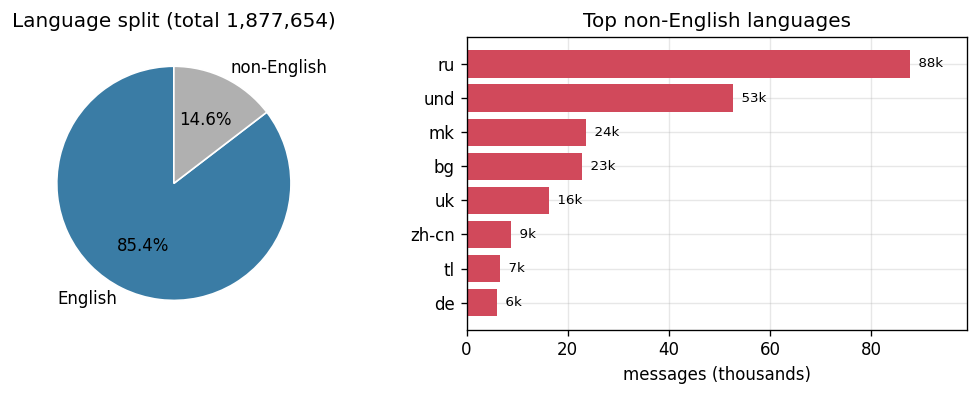

In [8]:
# Fig 5 — Language split + top non-English languages
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 3.4))
a1.pie([en_total, ne_total], labels=['English', 'non-English'], autopct='%1.1f%%',
       colors=[C_BLUE, C_GREY], startangle=90, wedgeprops={'edgecolor': 'white'})
a1.set_title(f'Language split (total {en_total+ne_total:,})')
top = lang.head(8)[::-1]
a2.barh(top.index, top.values / 1000, color=C_RED)
for i, v in enumerate(top.values):
    a2.text(v / 1000, i, f'  {v/1000:.0f}k', va='center', fontsize=8)
a2.set_xlabel('messages (thousands)'); a2.set_title('Top non-English languages')
a2.margins(x=0.13)
plt.tight_layout(); fig.savefig(PLOTS / 'dataset_language_split.png'); plt.show()
run_log.add_output(PLOTS / 'dataset_language_split.png')

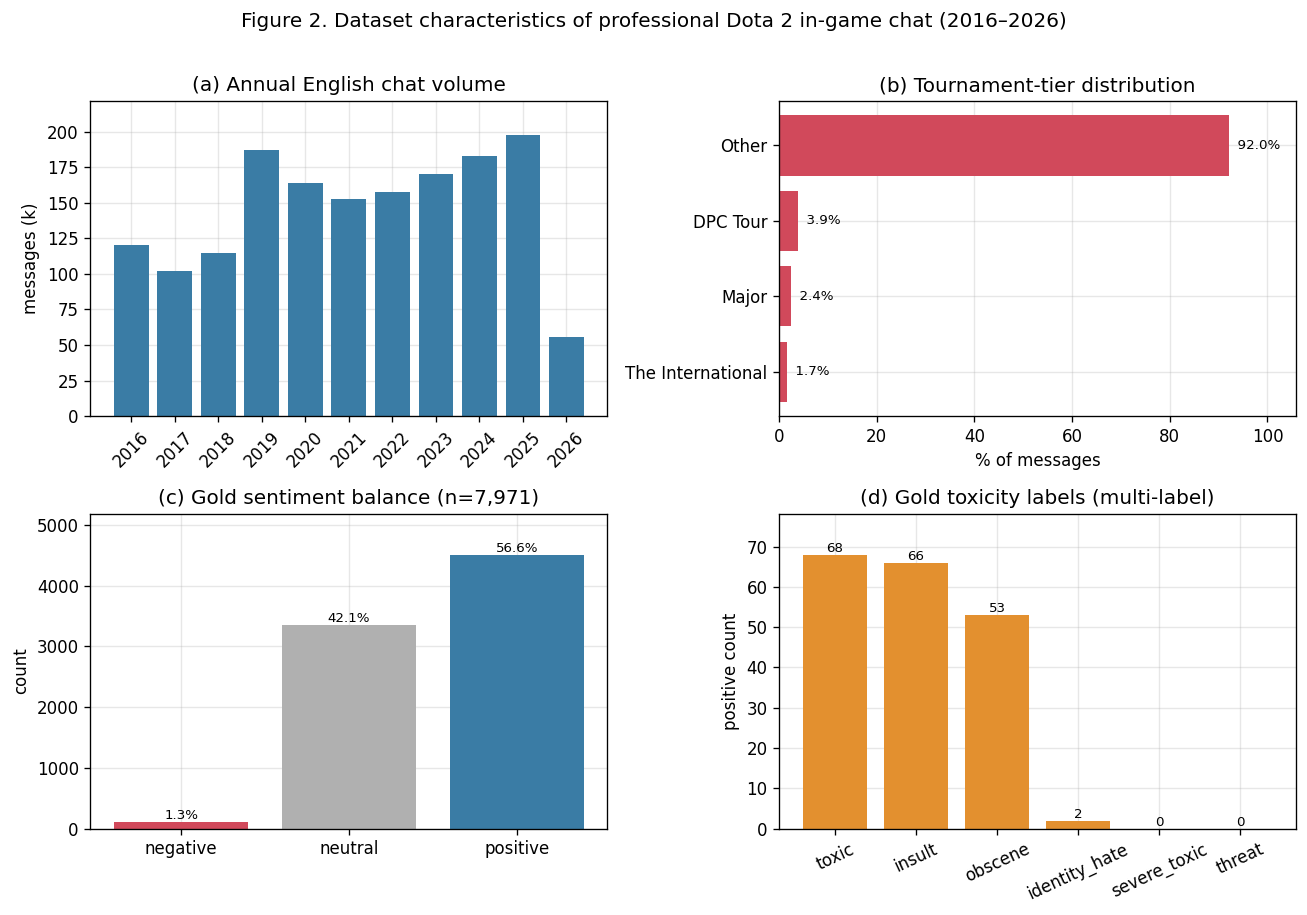

In [9]:
# Fig 6 — Combined panel for the manuscript (Figure 2)
fig, axs = plt.subplots(2, 2, figsize=(11, 7.5))

ax = axs[0, 0]
ax.bar(yr.index.astype(str), yr.values / 1000, color=C_BLUE)
ax.set_title('(a) Annual English chat volume'); ax.set_ylabel('messages (k)')
ax.tick_params(axis='x', rotation=45); ax.margins(y=0.12)

ax = axs[0, 1]
pct = (100 * tier / tier.sum()).sort_values()
ax.barh(pct.index, pct.values, color=C_RED)
for i, v in enumerate(pct.values):
    ax.text(v, i, f'  {v:.1f}%', va='center', fontsize=8)
ax.set_title('(b) Tournament-tier distribution'); ax.set_xlabel('% of messages'); ax.margins(x=0.15)

ax = axs[1, 0]
ax.bar(sent_counts.index, sent_counts.values, color=[cmap[s] for s in sent_counts.index])
for i, v in enumerate(sent_counts.values):
    ax.text(i, v, f'{100*v/n_gold:.1f}%', ha='center', va='bottom', fontsize=8)
ax.set_title(f'(c) Gold sentiment balance (n={n_gold:,})'); ax.set_ylabel('count'); ax.margins(y=0.15)

ax = axs[1, 1]
ax.bar(tc.index, tc.values, color=C_ORANGE)
for i, v in enumerate(tc.values):
    ax.text(i, v, str(v), ha='center', va='bottom', fontsize=8)
ax.set_title('(d) Gold toxicity labels (multi-label)'); ax.set_ylabel('positive count')
ax.tick_params(axis='x', rotation=25); ax.margins(y=0.15)

fig.suptitle('Figure 2. Dataset characteristics of professional Dota 2 in-game chat (2016–2026)',
             fontsize=12, y=1.01)
plt.tight_layout()
fig.savefig(PLOTS / 'dataset_characteristics_panel.png', bbox_inches='tight'); plt.show()
run_log.add_output(PLOTS / 'dataset_characteristics_panel.png')

In [10]:
run_log.save('reports/run_log.csv')
print('Done — 6 figures written to reports/plots/')

[run_log] 10_dataset_characteristics → 4.18s, 6 outputs, 0 warnings → reports\run_log.csv
Done — 6 figures written to reports/plots/
